In [1]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np

from astropy.table import Table
import sys, os, tqdm, glob
wdmodels_dir = os.environ['WDMODELS_DIR']
sys.path.append(wdmodels_dir)
import WD_models

plt.style.use("stefan.mplstyle")
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage[T1]{fontenc}\usepackage{lmodern}\usepackage{amsmath}",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

In [14]:
# Tyler's data
data = pd.read_csv("../data/tyler/WDMS_total_ages_correct_models_cut_down.csv")
data['tot_age_error_upper'] = data['tot_age_error_upper'].fillna(999)
data["total_age_lower_limit"] = data["tot_age"] - data["tot_age_error_lower"]
data = data.query("Teff > 0")
data = data[data.phot_bp_rp_excess_factor > 3 * (0.0059898 + 8.817481e-12*data.phot_g_mean_mag**7.618399)]
len(data), len(data[data.spectype != '0.0']), len(data[data.spec_source == 'GaiaXP']), len(data.query("10300 < Teff < 12000"))

(12460, 6457, 5265, 1437)

Text(0.5, 0, 'M<0.63, total age lower limit')

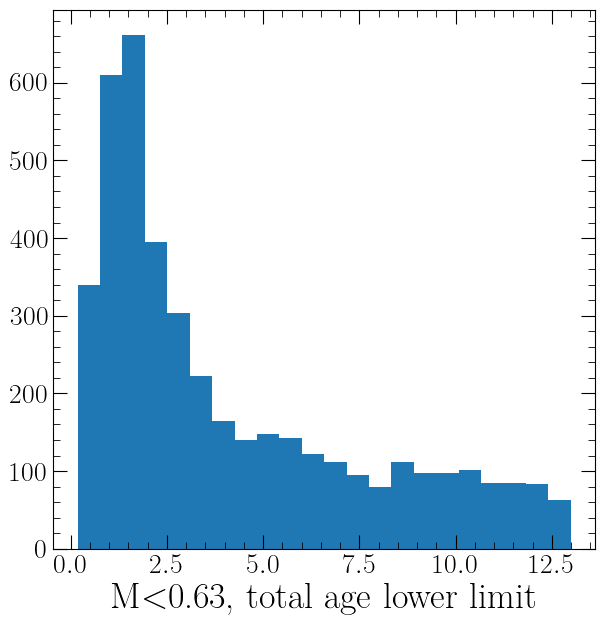

In [20]:
mask = (data.Mass < 0.63) & (data.total_age_lower_limit < 13) & (data.total_age_lower_limit > 0)
plt.hist(data[mask].total_age_lower_limit);
plt.xlabel("M<0.63, total age lower limit")

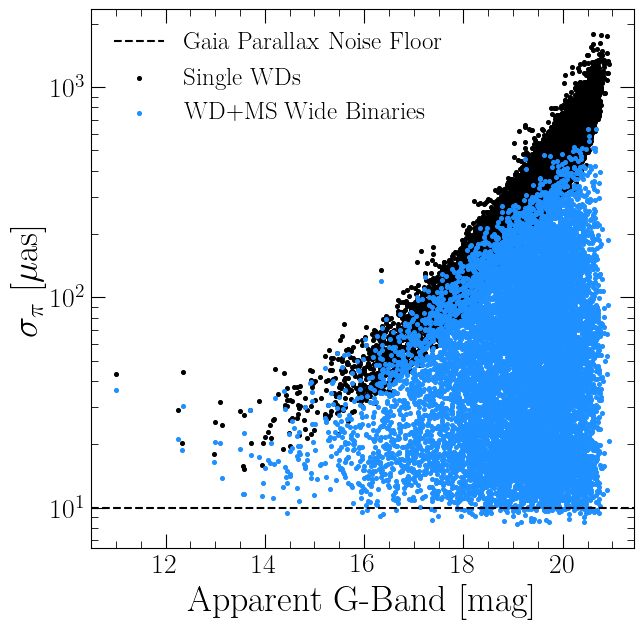

In [4]:
plt.axhline(y=10, c="k", ls="--", label="Gaia Parallax Noise Floor", zorder=10)
plt.scatter(data.phot_g_mean_mag, data.parallax_error*1e3, s=7, label="Single WDs", c="k")
plt.scatter(data.phot_g_mean_mag, data.e_wtd_par*1e3, s=7, label="WD+MS Wide Binaries", c="dodgerblue")
plt.xlabel("Apparent G-Band [mag]") ; plt.ylabel(r"$\sigma_\pi$ [$\mu$as]")
plt.legend(framealpha=0)
plt.yscale("log")

/tmp/ipykernel_141956/1231934885.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  candidate_pulators["e_Teff"] = np.abs(0.5*(candidate_pulators["e_Teff_upper"] - candidate_pulators["e_Teff_lower"]))


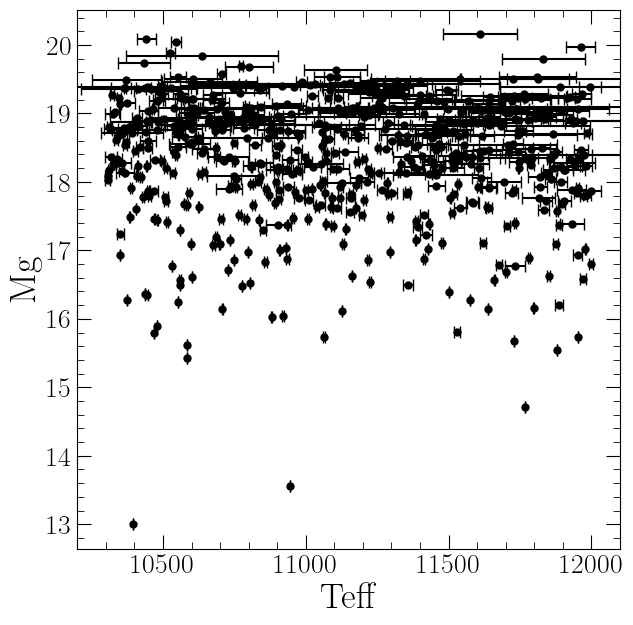

In [5]:
candidate_pulators = data.query("10300 < Teff < 12000 & spectype == 'DA'")
candidate_pulators["e_Teff"] = np.abs(0.5*(candidate_pulators["e_Teff_upper"] - candidate_pulators["e_Teff_lower"]))
#candidate_pulators.to_csv("gleek.csv")
plt.errorbar(candidate_pulators.Teff, candidate_pulators.phot_g_mean_mag, xerr=candidate_pulators.e_Teff, fmt="o", capsize=4, c="k");
plt.xlim(12100, 10200)
plt.xlabel("Teff") ; plt.ylabel("Mg") ; plt.gca().invert_xaxis()
#candidate_pulators.query("phot_g_mean_mag < 18")[["source_id", "phot_g_mean_mag"]]

In [6]:
#### Table 1 -- Spectral Types in the WD+MS Sample

# normalise spectype strings
_st = data['spectype'].fillna('').astype(str).str.upper().str.replace(':', '', regex=False).str.strip()

def _group(s):
    if s in ('0.0', '', 'NAN'): return None
    if s.startswith('DA') and not (s.startswith('DAB') or s.startswith('DBA')): return 'DA'
    if s.startswith('DB') or s.startswith('DAB') or s.startswith('DBA'): return 'DB'
    if s.startswith('DC'): return 'DC'
    if s.startswith('DQ'): return 'DQ'
    if s.startswith('DZ'): return 'DZ'
    return 'Other'

_grp = _st.map(_group)

n_tot  = _grp.value_counts()
n_xp   = _grp[data['spec_source'] == 'GaiaXP'].value_counts()

order = ['DA', 'DB', 'DC', 'DQ', 'DZ', 'Other']
table1 = pd.DataFrame({
    r'$N_{\rm tot}$':      n_tot.reindex(order).fillna(0).astype(int),
    r'$N_{\rm Gaia\,XP}$': n_xp.reindex(order).fillna(0).astype(int),
})
table1.index.name = 'Spectral Type'
table1.style.set_caption('Spectral Types in the WD+MS Sample')


,$N_{\rm tot}$,"$N_{\rm Gaia\,XP}$"
Spectral Type,,
DA,5272,4419
DB,419,316
DC,604,433
DQ,64,32
DZ,86,60
Other,12,5


Mean WD Mag: 19.12056918894307
Mean MS Mag: 15.660177385248796


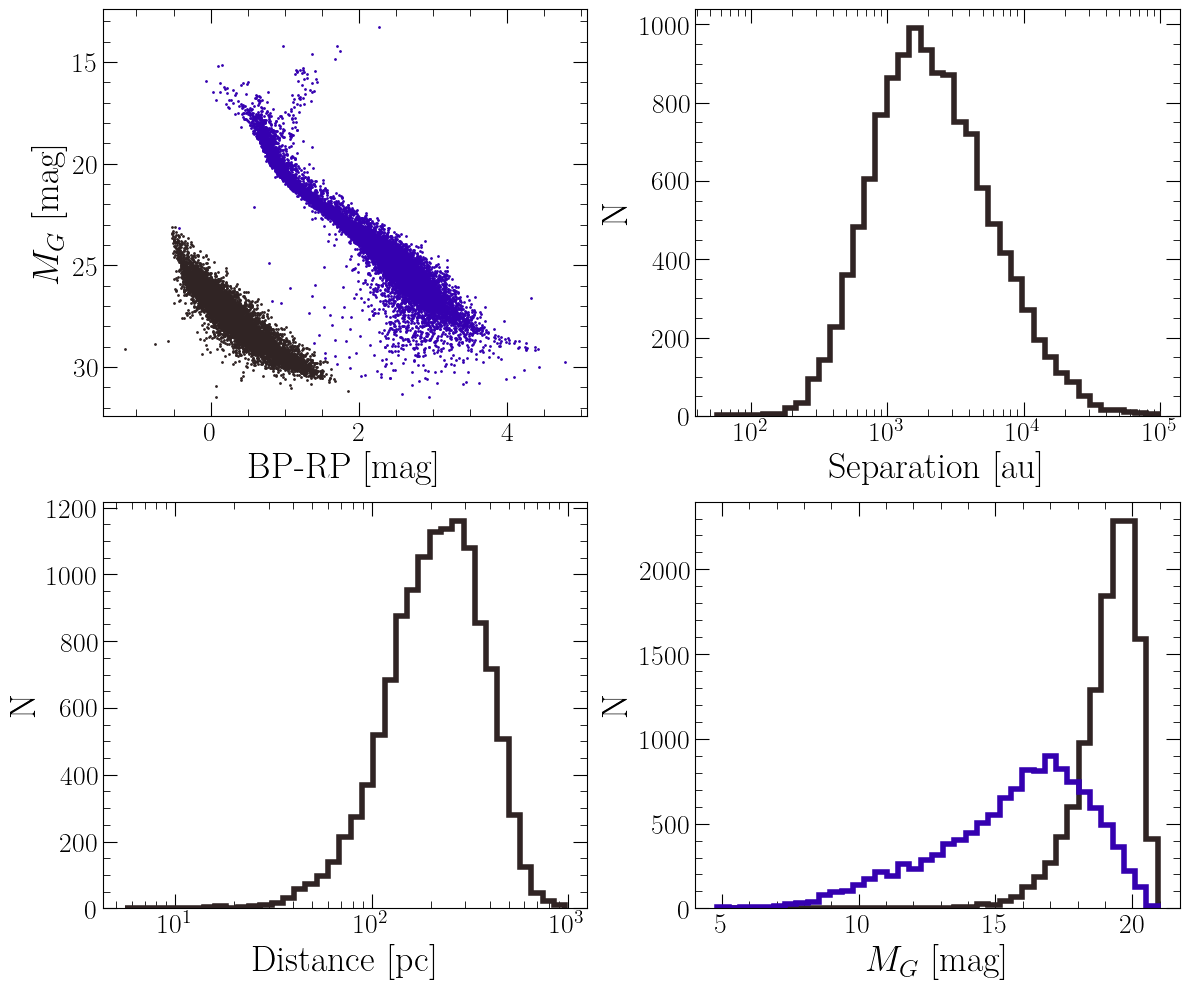

In [7]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(12, 10))

wd_color = "#302424" ; ms_color = "#3500b0"


ax[0,0].scatter(data.bp_rp, data.phot_g_mean_mag + 5*np.log10(data.wtd_par) + 5, s=1, c=wd_color, rasterized=True)
ax[0,0].scatter(data.ms_bp_rp, data.ms_phot_g_mean_mag + 5*np.log10(data.wtd_par) + 5, s=1, c=ms_color, rasterized=True)
ax[0,0].set_xlabel("BP-RP [mag]") ; ax[0,0].set_ylabel("$M_G$ [mag]")
ax[0,0].invert_yaxis()


sep_logbins = np.logspace(np.log10(min(data.sep_AU)),np.log10(max(data.sep_AU)), 40)
ax[0,1].hist(data.sep_AU, bins=sep_logbins, color=wd_color, histtype="step", linewidth=4);
ax[0,1].set_xlabel("Separation [au]") ; ax[0,1].set_ylabel("N")
ax[0,1].set_xscale("log")


dist_logbins = np.logspace(np.log10(min(1000/data.wtd_par)),np.log10(max(1000/data.wtd_par)), 40)
ax[1,0].hist(1000/data.wtd_par, bins=dist_logbins, color=wd_color, histtype="step", linewidth=4);
ax[1,0].set_xlabel("Distance [pc]") ; ax[1,0].set_ylabel("N")
ax[1,0].set_xscale("log")

color_bins = np.linspace(
    min(np.min(data.phot_g_mean_mag), np.min(data.ms_phot_g_mean_mag)),
    max(np.max(data.phot_g_mean_mag), np.max(data.ms_phot_g_mean_mag)), 
    40
)
ax[1,1].hist(data.phot_g_mean_mag, bins=color_bins, color=wd_color, histtype="step", linewidth=4);
ax[1,1].hist(data.ms_phot_g_mean_mag, bins=color_bins, color=ms_color, histtype="step", linewidth=4);
ax[1,1].set_xlabel("$M_G$ [mag]") ; ax[1,1].set_ylabel("N")
print(f"Mean WD Mag: {np.mean(data.phot_g_mean_mag)}")
print(f"Mean MS Mag: {np.mean(data.ms_phot_g_mean_mag)}")

fig.tight_layout()
plt.savefig("figures_original/sample_summary.pdf")

In [8]:
crys = pd.read_csv("../data/merge_data/crystallization.csv")

model = WD_models.load_model(low_mass_model='Bedard2020',
                             middle_mass_model='Bedard2020',
                             high_mass_model='Bedard2020',
                             atm_type='H',
                             HR_bands=('bp3-rp3', 'G3'))

logg_20pct = model["HR_to_logg"](crys["bprp_20pct"].to_numpy(), crys["gabs_20pct"].to_numpy())
mass_20pct = model["HR_to_mass"](crys["bprp_20pct"].to_numpy(), crys["gabs_20pct"].to_numpy())
radius_20pct = np.sqrt(mass_20pct * 10**(4.437 - logg_20pct))
teff_20pct = 10**model["HR_to_logteff"](crys["bprp_20pct"].to_numpy(), crys["gabs_20pct"].to_numpy())

logg_80pct = model["HR_to_logg"](crys["bprp_80pct"].to_numpy(), crys["gabs_80pct"].to_numpy())
mass_80pct = model["HR_to_mass"](crys["bprp_80pct"].to_numpy(), crys["gabs_80pct"].to_numpy())
radius_80pct = np.sqrt(mass_80pct * 10**(4.437 - logg_80pct))
teff_80pct = 10**model["HR_to_logteff"](crys["bprp_80pct"].to_numpy(), crys["gabs_80pct"].to_numpy())

Mean Mass = 0.5828162215714443


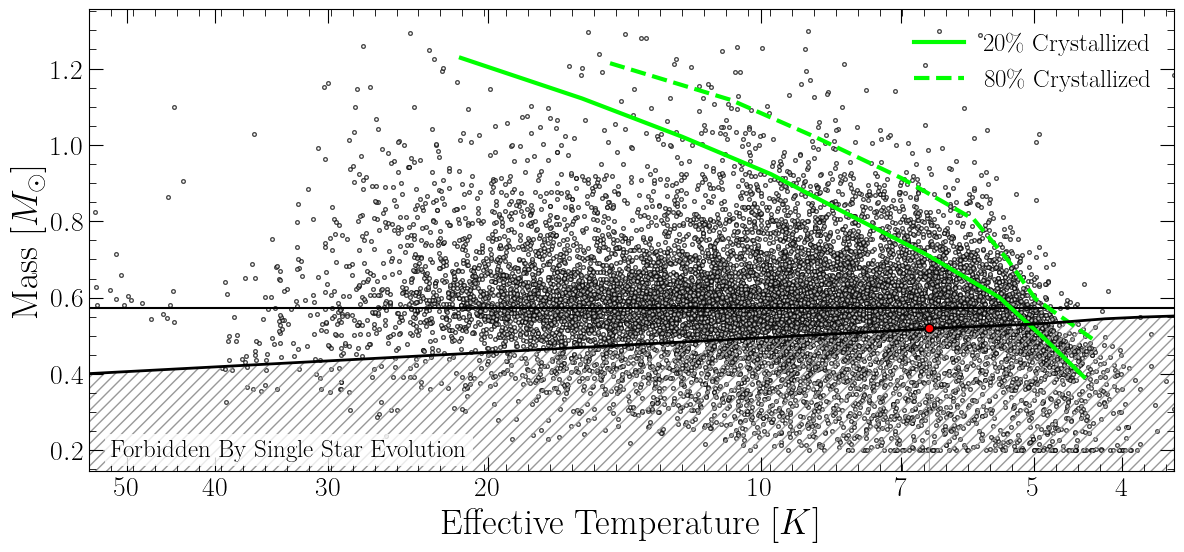

In [9]:
fig, ax = plt.subplots(figsize=(14,6))

ax.scatter(np.log10(data.Teff), data.Mass, 
           c='white', edgecolor="k", 
           alpha=0.7, s=7,  zorder=1,
           rasterized=True);
ax.axhline(np.nanmedian(data.Mass), c="k")
ax.plot(np.log10(teff_20pct), mass_20pct, c="lime", lw=3, label="20\\% Crystallized", zorder=2)
ax.plot(np.log10(teff_80pct), mass_80pct, c="lime", ls="--", lw=3, label="80\\% Crystallized", zorder=2)

# figure out the range of allowable temperatures ---------------------

ifmr = pd.read_csv("../data/MESA_IFMR/ifmr_data.csv")
ylims = ax.get_ylim()

mask = ifmr.teff_max > 4000
z = np.polyfit(np.log10(ifmr.loc[mask, "teff_max"]), ifmr.loc[mask, "M_final"], 1)
p = np.poly1d(z)

min_t = ax.get_xlim()[1]
max_t = max(np.log10(ifmr.teff_max))
t_fit = np.linspace(min_t, max_t, 3)
M_extrap = p(t_fit)
tarr = np.concatenate((t_fit, np.log10(ifmr.teff_max)))
Marr = np.concatenate((M_extrap, ifmr.M_final))

# Hatched region below the IFMR
ax.fill_between(
    np.log10(ifmr.teff_max), ifmr.M_final,
    ylims[0],                               # fill down to the plot floor
    hatch="///", facecolor="none",
    edgecolor="0.6", linewidth=0.4, zorder=1,
)
ax.fill_between(
    t_fit, p(t_fit),
    ylims[0],
    hatch="///", facecolor="none",
    edgecolor="0.6", linewidth=0.4, zorder=1,
)

# Clean fit line
ax.plot(t_fit, p(t_fit), c="k", lw=2, zorder=7)
ax.plot(np.log10(ifmr.teff_max), ifmr.M_final, c="k", lw=2, zorder=7)
ax.scatter([max_t], min(ifmr.M_final), s=40, c="red", edgecolor="k", zorder=100)
ax.text(0.02, 0.07, "Forbidden By Single Star Evolution",
        ha='left', va='top', fontsize=18, transform=ax.transAxes,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
ax.set_ylim(ylims)

ticks_kK = np.array([50, 40, 30, 20, 10, 7, 5, 4])   # in 10^3 K
tick_locs = np.log10(ticks_kK * 1e3)
ax.set_xticks(tick_locs)
ax.set_xticklabels([f"{t:g}" for t in ticks_kK])
ax.set_xlabel("Effective Temperature [$K$]") ; ax.set_ylabel("Mass [$M_\\odot$]")
ax.invert_xaxis()
ax.set_xlim(np.log10(55000), np.log10(3500))

ax.legend(framealpha=0)

fig.savefig("figures_original/mass_teff.pdf")

print(f"Mean Mass = {np.mean(data.Mass)}")

plx Improvement Ratio: 6.387623455542411
Mass Improvement Ratio: 3.2565434432067444


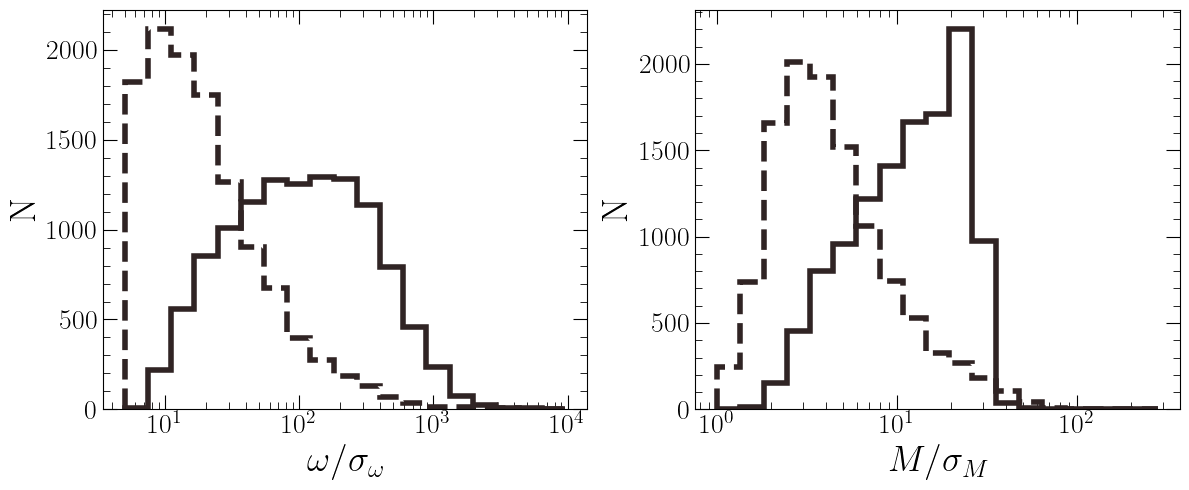

In [10]:
## compare the weighted parallaxes

ngf_data = pd.read_parquet("~/observational/catalogs/nicola_wds/ngf21_wds.pqt")
ngf_data = ngf_data[["GaiaEDR3", "MassH", "e_MassH", "Plx", "e_Plx"]]
data_ngf = pd.merge(data, ngf_data, left_on="source_id", right_on="GaiaEDR3")
data_ngf["e_Mass"] = 0.5*(data_ngf["e_Mass_lower"] + data_ngf["e_Mass_upper"])

fig, ax = plt.subplots(ncols=2, figsize=(12, 5))

# plot the parallax over error
all_vals = np.concatenate([data_ngf.wtd_par / data_ngf.e_wtd_par, data_ngf.Plx / data_ngf.e_Plx])
all_vals = all_vals[np.isfinite(all_vals) & (all_vals > 0) & (all_vals < 1e4)]

plx_logbins = np.logspace(
    np.log10(np.min(all_vals)),
    np.log10(np.max(all_vals)),
    20
)
ax[0].hist(data_ngf.wtd_par / data_ngf.e_wtd_par, bins=plx_logbins, color=wd_color, histtype="step", linewidth=4)
ax[0].hist(data_ngf.Plx / data_ngf.e_Plx, bins=plx_logbins, color=wd_color, histtype="step", ls="--", linewidth=4)
ax[0].set_xlabel(r"$\omega / \sigma_\omega$") ; ax[0].set_ylabel("N")
ax[0].set_xscale("log")

wtd_psnr = data_ngf.wtd_par / data_ngf.e_wtd_par
ngf_psnr = data_ngf.Plx / data_ngf.e_Plx
print(f"plx Improvement Ratio: {np.nanmedian(wtd_psnr) / np.nanmedian(ngf_psnr)}")

# combine and clean
all_vals = np.concatenate([data_ngf.Mass / data_ngf.e_Mass, data_ngf.MassH / data_ngf.e_MassH])
all_vals = all_vals[np.isfinite(all_vals) & (all_vals > 0) & (all_vals < 1e4)]

mass_logbins = np.logspace(
    np.log10(np.min(all_vals)),
    np.log10(np.max(all_vals)),
    20
)
ax[1].hist(data_ngf.Mass / data_ngf.e_Mass, bins=mass_logbins, color=wd_color, histtype="step", linewidth=4)
ax[1].hist(data_ngf.MassH / data_ngf.e_MassH, bins=mass_logbins, color=wd_color, histtype="step", ls="--", linewidth=4)
ax[1].set_xlabel(r"$M / \sigma_M$") ; ax[1].set_ylabel("N")
ax[1].set_xscale("log")

wtd_msnr = data_ngf.Mass / data_ngf.e_Mass
ngf_msnr = data_ngf.MassH / data_ngf.e_MassH
print(f"Mass Improvement Ratio: {np.nanmedian(wtd_msnr) / np.nanmedian(ngf_msnr)}")

fig.tight_layout()
plt.savefig("figures_original/uncertainty_improvement.pdf")

Text(0, 0.5, 'N')

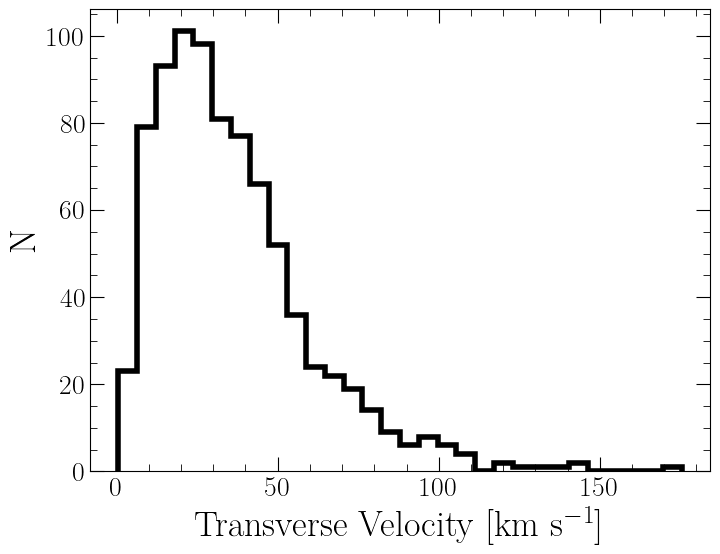

In [11]:
### do the age-velocity dispersion stuff
data["e_tot_age"] = 0.5*(data["tot_age_error_upper"] - data["tot_age_error_lower"])
data_clean = data.query("e_tot_age / tot_age < 0.2 & Mass > 0.63 & spectype != '0.0'").copy()
data_clean.loc[:,"vtransverse"] = (4.74 / data_clean.wtd_par)*np.sqrt((data_clean.pmra**2)+(data_clean.pmdec**2))

fig, ax = plt.subplots(figsize=(8,6))
ax.hist(data_clean.vtransverse, color="k", histtype="step", ls="-", linewidth=4);
ax.set_xlabel("Transverse Velocity [km s$^{-1}$]")
ax.set_ylabel("N")

In [12]:
set(data.spectype)

{'0.0',
 'DA',
 'DA+dM',
 'DA+dM:',
 'DA:',
 'DA:+dM',
 'DAB',
 'DAH',
 'DAH:',
 'DAO',
 'DAZ',
 'DAZ?',
 'DB',
 'DB+dM',
 'DB:',
 'DBA',
 'DBA:',
 'DBAZ',
 'DBAZH:',
 'DBZ',
 'DBZA',
 'DC',
 'DC+dM',
 'DC+dM:',
 'DC:',
 'DO',
 'DOZ',
 'DQ',
 'DQ:',
 'DQP',
 'DZ',
 'DZ:',
 'DZA',
 'DZAH:',
 'hotsubdwarf'}

In [13]:
#### implement the age-metallicity figures
tyler_GALAH  = pd.read_csv("../data/tyler/tyler_wdms_GALAH.csv").query("Teff_1 > 3200")
tyler_APOGEE = pd.read_csv("../data/tyler/tyler_wdms_APOGEE.csv").query("Teff_1 > 3200")
tyler_ASTRA  = pd.read_csv("../data/tyler/tyler_wdms_ASTRA.csv").query("Teff_1 > 3200")

tyler_GALAH['tot_age_error_upper']  = tyler_GALAH['tot_age_error_upper'].fillna(999)
tyler_APOGEE['tot_age_error_upper'] = tyler_APOGEE['tot_age_error_upper'].fillna(999)
tyler_ASTRA['tot_age_error_upper']  = tyler_ASTRA['tot_age_error_upper'].fillna(999)


# ── Metallicity rename maps ──────────────────────────────────────────
# All abundances stored as [X/Fe].
# GALAH: capitalised element symbols → lowercase  (Mg_fe → mg_fe)
# APOGEE: UPPER_CASE + _ERR/_FLAG → lower_case + e_/flag_
# ASTRA: [X/H] → [X/Fe] = [X/H] − [Fe/H], errors propagated

_galah_elems = [
    'Al', 'Ba', 'C', 'Ca', 'Ce', 'Co', 'Cr', 'Cr2', 'Cu', 'Eu',
    'K', 'La', 'Li', 'Mg', 'Mn', 'Mo', 'Na', 'Nd', 'Ni', 'O',
    'Rb', 'Ru', 'Sc', 'Sc2', 'Si', 'Sm', 'Sr', 'Ti', 'Ti2', 'V',
    'Y', 'Zn', 'Zr',
]
galah_rename = {}
for el in _galah_elems:
    lo = el.lower()
    galah_rename[f'{el}_fe']      = f'{lo}_fe'
    galah_rename[f'e_{el}_fe']    = f'e_{lo}_fe'
    galah_rename[f'flag_{el}_fe'] = f'flag_{lo}_fe'
    galah_rename[f'nr_{el}_fe']   = f'nr_{lo}_fe'

_apogee_fe_elems = [
    'AL', 'CA', 'CE', 'CI', 'CO', 'CR', 'CU', 'C',
    'K', 'MG', 'MN', 'NA', 'NI', 'N', 'O', 'P',
    'SI', 'S', 'TI', 'V', 'YB',
]
apogee_rename = {
    'FE_H': 'fe_h', 'FE_H_ERR': 'e_fe_h', 'FE_H_FLAG': 'flag_fe_h', 'FE_H_SPEC': 'fe_h_spec',
    'M_H':  'm_h',  'M_H_ERR':  'e_m_h',
    'ALPHA_M': 'alpha_m', 'ALPHA_M_ERR': 'e_alpha_m',
    'TIII_FE': 'ti3_fe', 'TIII_FE_ERR': 'e_ti3_fe',
    'TIII_FE_FLAG': 'flag_ti3_fe', 'TIII_FE_SPEC': 'ti3_fe_spec',
}
for el in _apogee_fe_elems:
    lo = el.lower()
    apogee_rename[f'{el}_FE']      = f'{lo}_fe'
    apogee_rename[f'{el}_FE_ERR']  = f'e_{lo}_fe'
    apogee_rename[f'{el}_FE_FLAG'] = f'flag_{lo}_fe'
    apogee_rename[f'{el}_FE_SPEC'] = f'{lo}_fe_spec'

# ASTRA: rename flags to flag_x_fe; fe_h_flags handled separately
_astra_h_elems = [
    'al', 'c', 'ca', 'ce', 'co', 'cr', 'cu',
    'k', 'mg', 'mn', 'n', 'na', 'nd', 'ni', 'o',
    'p', 's', 'si', 'ti', 'v',
]
astra_rename = {'fe_h_flags': 'flag_fe_h', 'c_12_13_flags': 'flag_c_12_13'}
for el in _astra_h_elems:
    astra_rename[f'{el}_h_flags'] = f'flag_{el}_fe'

# ── Rename and tag ─────────────────────────────────────────────
g = tyler_GALAH.rename(columns=galah_rename).assign(survey='GALAH')
a = tyler_APOGEE.rename(columns=apogee_rename).assign(survey='APOGEE')
s = tyler_ASTRA.rename(columns=astra_rename).assign(survey='ASTRA')

# ── Convert ASTRA [X/H] → [X/Fe] = [X/H] − [Fe/H] ──────────────────────
for el in _astra_h_elems:
    s[f'{el}_fe']   = s[f'{el}_h'] - s['fe_h']
    s[f'e_{el}_fe'] = np.sqrt(s[f'e_{el}_h']**2 + s['e_fe_h']**2)
    s = s.drop(columns=[f'{el}_h', f'e_{el}_h'], errors='ignore')

# ── Collect standardised metallicity column names ──────────────────
metal_cols = (
    set(galah_rename.values()) |
    set(apogee_rename.values()) |
    {f'{el}_fe'      for el in _astra_h_elems} |
    {f'e_{el}_fe'    for el in _astra_h_elems} |
    {f'flag_{el}_fe' for el in _astra_h_elems} |
    {'fe_h', 'e_fe_h', 'flag_fe_h',
     'alpha_fe', 'e_alpha_fe', 'flag_alpha_fe',
     'alpha_m', 'e_alpha_m',
     'alpha_m_atm', 'e_alpha_m_atm',
     'm_h', 'e_m_h', 'm_h_atm', 'e_m_h_atm',
     'c_m_atm', 'e_c_m_atm', 'n_m_atm', 'e_n_m_atm',
     'c_12_13', 'e_c_12_13', 'flag_c_12_13',
     'fe_h_atmo',}
)

# Base WD+MS columns: keep non-metallicity columns present in >=2 surveys
from collections import Counter
all_non_metal = [
    c for df in (g, a, s)
    for c in df.columns if c not in metal_cols and c != 'survey'
]
base_cols = [c for c, n in Counter(all_non_metal).items() if n >= 2]

# ── Combine and trim ─────────────────────────────────────────────
combined = pd.concat([g, a, s], ignore_index=True)
keep = ['survey'] + base_cols + [c for c in metal_cols if c in combined.columns]
combined = combined[[c for c in keep if c in combined.columns]]

# ── Apply quality flags ────────────────────────────────────────────
# APOGEE / ASTRA: any non-zero flag -> NaN
# GALAH: flag > 1 -> NaN  (flag == 1 is a warning but still usable)
flag_threshold = {'GALAH': 1, 'APOGEE': 0, 'ASTRA': 0}

for flag_col in [c for c in combined.columns if c.startswith('flag_') and c in metal_cols]:
    base = flag_col[len('flag_'):]
    cols_to_null = [c for c in [base, f'e_{base}'] if c in combined.columns]
    if not cols_to_null:
        continue
    for survey, threshold in flag_threshold.items():
        bad = (combined['survey'] == survey) & (combined[flag_col].fillna(0) > threshold)
        combined.loc[bad, cols_to_null] = np.nan

combined = combined.query("fe_h > -900")

totalage = combined.Mass > 0.63
coolingage = ~totalage

print(f'Combined: {len(combined)} rows  ({len(g)} GALAH, {len(a)} APOGEE, {len(s)} ASTRA)')
print(f'Columns: {len(combined.columns)}')
print(combined.groupby('survey')[['fe_h', 'mg_fe']].count())


Combined: 1105 rows  (137 GALAH, 324 APOGEE, 960 ASTRA)
Columns: 366
        fe_h  mg_fe
survey             
APOGEE   249    248
ASTRA    753    742
GALAH    103     92


In [14]:
lamost = pd.read_csv("../data/merge/wdms_lamost.csv")
lamost = lamost.rename(columns={'[Fe/H]': 'fe_h'})
lamost = lamost[lamost.Teff > 0]
lamost = lamost.sort_values('snrg', ascending=False).drop_duplicates(subset=['source_id'])
lamost = lamost.query("fe_h > -900")
print(f'LAMOST: {len(lamost)} unique sources, {(lamost.Mass > 0.63).sum()} with reliable total ages')

LAMOST: 425 unique sources, 93 with reliable total ages


In [15]:
import pyvo

tap_service = pyvo.dal.TAPService("http://TAPVizieR.u-strasbg.fr/TAPVizieR/tap/")

id_list = ", ".join(str(int(i)) for i in lamost["ObsID"].dropna())
QUERY = f"""SELECT "ObsID", "e_[Fe/H]" as e_FeH
    FROM "V/156/dr7slrs"
    WHERE "ObsID" IN ({id_list})
"""
feh_errors = tap_service.search(QUERY).to_table().to_pandas()
lamost = lamost.merge(feh_errors.rename(columns={"e_FeH": "e_fe_h"}), on="ObsID", how="left")
n_matched = feh_errors.shape[0]
n_nonnull = lamost["e_fe_h"].notna().sum()
print(f"Matched {n_matched} / {len(lamost)} LAMOST entries with Fe/H errors")
print(f"e_fe_h coverage: {n_nonnull} non-null")

Matched 425 / 425 LAMOST entries with Fe/H errors
e_fe_h coverage: 425 non-null


659 37
mean fe/h for da: -0.12 +/- 0.01
mean fe/h for db: -0.09 +/- 0.04
KS statistic: 0.146, p-value: 0.405


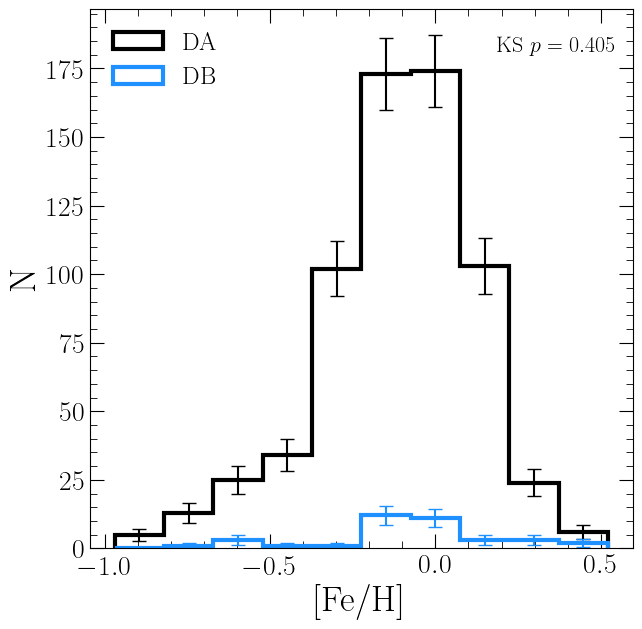

In [16]:
from scipy import stats

feh_da = pd.concat([
    combined.query("spectype == 'DA'")[['fe_h']],
    lamost.query("spectype == 'DA'")[['fe_h']],
])
feh_db = pd.concat([
    combined.query("spectype == 'DB'")[['fe_h']],
    lamost.query("spectype == 'DB'")[['fe_h']],
])
print(len(feh_da), len(feh_db))
print(f"mean fe/h for da: {np.mean(feh_da.fe_h):1.2f} +/- {np.std(feh_da.fe_h) / np.sqrt(len(feh_da)):1.2f}")
print(f"mean fe/h for db: {np.mean(feh_db.fe_h):1.2f} +/- {np.std(feh_db.fe_h) / np.sqrt(len(feh_db)):1.2f}")

ks_stat, p_value = stats.ks_2samp(feh_da['fe_h'].dropna(), feh_db['fe_h'].dropna())
print(f"KS statistic: {ks_stat:.3f}, p-value: {p_value:.3f}")

fig, ax = plt.subplots()

da_counts, bins = np.histogram(feh_da['fe_h'].dropna())
db_counts, _ = np.histogram(feh_db['fe_h'].dropna(), bins=bins)

bin_centers = 0.5 * (bins[:-1] + bins[1:])

ax.errorbar(bin_centers, da_counts, yerr=np.sqrt(da_counts), 
            fmt='none', color='k', capsize=5)
ax.errorbar(bin_centers, db_counts, yerr=np.sqrt(db_counts), 
            fmt='none', color='dodgerblue', capsize=5)

ax.hist(feh_da['fe_h'], bins=bins, histtype='step', color='k', linewidth=3, label="DA")
ax.hist(feh_db['fe_h'], bins=bins, histtype='step', color='dodgerblue', linewidth=3, label="DB")

ax.text(0.75, 0.95, f"KS $p = {p_value:.3f}$", transform=ax.transAxes, 
        va='top', fontsize=16)

ax.set_xlabel('[Fe/H]') ; ax.set_ylabel('N')
ax.legend(framealpha=0)

fig.savefig("figures_original/da_db_hist.pdf")

174
GALAH          slope = -7.458 +/- 3.106 Gyr/dex
APOGEE + ASTRA slope = -5.754 +/- 1.102 Gyr/dex
Weighted mean  slope = -5.945 +/- 1.039 Gyr/dex


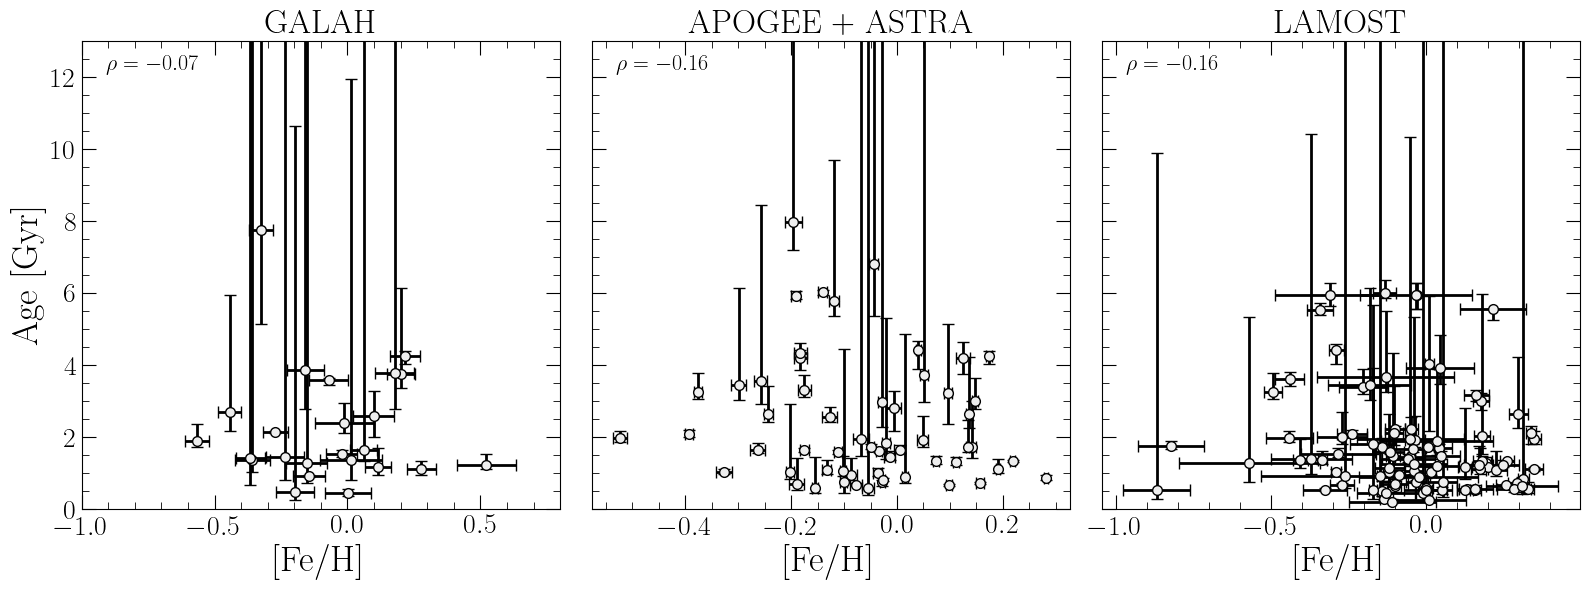

In [17]:
#### Age-Metallicity Figure
from scipy.odr import ODR, Model, RealData
from scipy.stats import spearmanr

def linear(B, x):
    return B[0] * x + B[1]

def odr_fit(df, x_col, y_col, sx_col, sy_lo_col, sy_hi_col):
    """ODR linear fit; sy is the mean of asymmetric error bars."""
    d = df[[x_col, y_col, sx_col, sy_lo_col, sy_hi_col]].copy()
    d['sy'] = 0.5 * (d[sy_lo_col] + d[sy_hi_col])
    d = d.replace(0, np.nan).dropna()
    data = RealData(d[x_col].values, d[y_col].values,
                    sx=d[sx_col].values, sy=d['sy'].values)
    out = ODR(data, Model(linear), beta0=[-3., 6.]).run()
    return out.beta[0], out.beta[1], out.sd_beta[0], out.sd_beta[1]

xfit = np.linspace(-1.3, 0.7, 200)

fig, ax = plt.subplots(ncols=3, figsize=(16,6), sharey=True)

# ── GALAH ─────────────────────────────────────────────────────────────────
combined_GALAH = combined.query("survey == 'GALAH'")
sel_g = combined_GALAH.loc[totalage]
ax[0].errorbar(
    sel_g['fe_h'], sel_g['tot_age'],
    xerr=sel_g['e_fe_h'],
    yerr=sel_g[['tot_age_error_lower', 'tot_age_error_upper']].values.T,
    fmt='o', color='#eeeeee', markeredgecolor='k', ecolor='k', lw=2, capsize=4, markersize=7,
)
xmin, xmax = ax[0].get_xlim()

m_g, b_g, sm_g, sb_g = odr_fit(
    sel_g, 'fe_h', 'tot_age', 'e_fe_h', 'tot_age_error_lower', 'tot_age_error_upper'
)
rho_g, pval_g = spearmanr(sel_g['fe_h'], sel_g['tot_age'], nan_policy='omit')

#ax[0].plot(xfit, m_g * xfit + b_g, color='red', lw=2, zorder=5)
ax[0].text(0.05, 0.97,
    f'$\\rho = {rho_g:.2f}$',
    transform=ax[0].transAxes, va='top', fontsize=16,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))
ax[0].set_ylim(0, 13)
ax[0].set_xlabel('[Fe/H]') ; ax[0].set_ylabel('Age [Gyr]')
ax[0].set_title('GALAH', fontsize=24)
ax[0].set_xlim(xmin, xmax)
ax[0].set_xlim(-1.0, 0.8)

# ── APOGEE + ASTRA ────────────────────────────────────────────────────────
combined_APOGEE = combined.query("survey == 'APOGEE' or survey == 'ASTRA'")
sel_a = combined_APOGEE.loc[totalage]
ax[1].errorbar(
    sel_a['fe_h'], sel_a['tot_age'],
    xerr=sel_a['e_fe_h'],
    yerr=sel_a[['tot_age_error_lower', 'tot_age_error_upper']].values.T,
    fmt='o', color='#eeeeee', markeredgecolor='k', ecolor='k', lw=2, capsize=4, markersize=7,
)
xmin, xmax = ax[1].get_xlim()

m_a, b_a, sm_a, sb_a = odr_fit(
    sel_a, 'fe_h', 'tot_age', 'e_fe_h', 'tot_age_error_lower', 'tot_age_error_upper'
)
rho_a, pval_a = spearmanr(sel_a['fe_h'], sel_a['tot_age'], nan_policy='omit')
#ax[1].plot(xfit, m_a * xfit + b_a, color='red', lw=2, zorder=5)
ax[1].text(0.05, 0.97,
    f'$\\rho = {rho_a:.2f}$',
    transform=ax[1].transAxes, va='top', fontsize=16, 
    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.0))
ax[1].set_xlabel('[Fe/H]')
ax[1].set_title('APOGEE + ASTRA', fontsize=24)
ax[1].set_xlim(xmin, xmax)

# ── LAMOST ────────────────────────────────────────────────────────────────
sel_l = lamost[lamost.Mass > 0.63].dropna(subset=['fe_h', 'tot_age', 'tot_age_error_lower', 'tot_age_error_upper'])
ax[2].errorbar(
    sel_l['fe_h'], sel_l['tot_age'],
    xerr=sel_l["e_fe_h"],
    yerr=sel_l[['tot_age_error_lower', 'tot_age_error_upper']].values.T,
    fmt='o', color='#eeeeee', markeredgecolor='k', ecolor='k', lw=2, capsize=4, markersize=7,
)
xmin, xmax = ax[2].get_xlim()

rho_l, pval_l = spearmanr(sel_l['fe_h'], sel_l['tot_age'], nan_policy='omit')
ax[2].text(0.05, 0.97,
    f'$\\rho = {rho_l:.2f}$',
    transform=ax[2].transAxes, va='top', fontsize=16,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0))
ax[2].set_xlabel('[Fe/H]')
ax[2].set_title('LAMOST', fontsize=24)
ax[2].set_xlim(xmin, xmax)

print(len(sel_g) + len(sel_a) + len(sel_l))

# ── Slopes summary ──────────────────────────────────────────────────────────
slopes = np.array([m_g, m_a])
sigmas = np.array([sm_g, sm_a])
w = 1.0 / sigmas**2
m_wtd  = np.sum(w * slopes) / np.sum(w)
sm_wtd = 1.0 / np.sqrt(np.sum(w))

print(f'GALAH          slope = {m_g:.3f} +/- {sm_g:.3f} Gyr/dex')
print(f'APOGEE + ASTRA slope = {m_a:.3f} +/- {sm_a:.3f} Gyr/dex')
print(f'Weighted mean  slope = {m_wtd:.3f} +/- {sm_wtd:.3f} Gyr/dex')

fig.tight_layout()
plt.savefig("figures_original/age_metallicity.pdf")

/tmp/ipykernel_141956/2503181791.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined["a_li"] = combined["li_fe"] + combined["fe_h"] + 0.96
/tmp/ipykernel_141956/2503181791.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  combined["e_a_li"] = np.sqrt(combined["e_li_fe"]**2 + combined["e_fe_h"]**2)


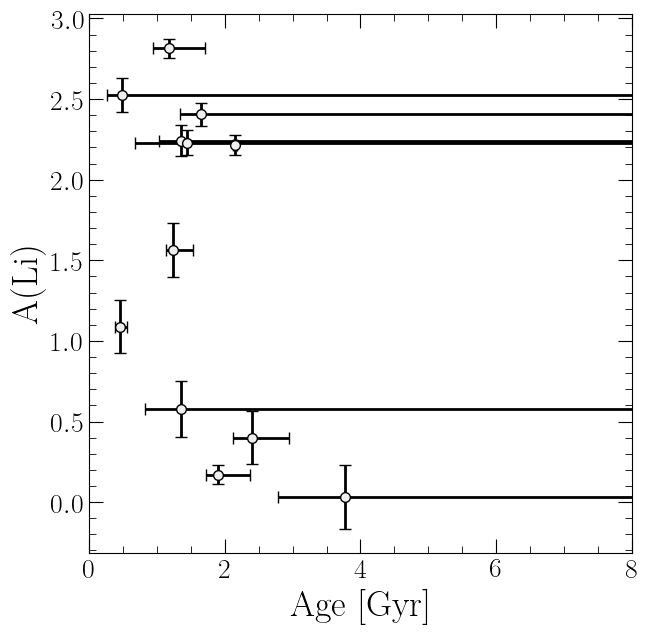

In [18]:
#### Li Abundance Figure

combined["a_li"] = combined["li_fe"] + combined["fe_h"] + 0.96
combined["e_a_li"] = np.sqrt(combined["e_li_fe"]**2 + combined["e_fe_h"]**2)

fig, ax = plt.subplots()

ax.errorbar(
    combined.loc[totalage,"tot_age"],
    combined.loc[totalage,"a_li"], 
    xerr=combined.loc[totalage,["tot_age_error_lower", "tot_age_error_upper"]].values.T, 
    yerr=combined.loc[totalage,"e_a_li"], 
    fmt="o", color="#eeeeee", markeredgecolor="k", ecolor="k", lw=2, capsize=4, markersize=7, 
)
#ax.errorbar(
#    combined.loc[coolingage,"cool_age"],
#    combined.loc[coolingage,"a_li"], 
#    xerr=0.5, xlolims=True, 
#    yerr=combined.loc[coolingage,"e_a_li"], zorder=0,
#    fmt="o", color="#426dfc", markeredgecolor="k", ecolor="k", lw=2, capsize=2, markersize=4, 
#)

ax.set_xlim(0, 8)
ax.set_xlabel("Age [Gyr]") ; ax.set_ylabel("A(Li)") 
plt.savefig("figures_original/age_li.pdf")

           ms_source_id  alpha_fe  e_alpha_fe   tot_age  tot_age_error_lower  \
54  4653722929233862144  0.439228    0.021648  1.892124             0.173088   

    tot_age_error_upper  
54             0.479473  


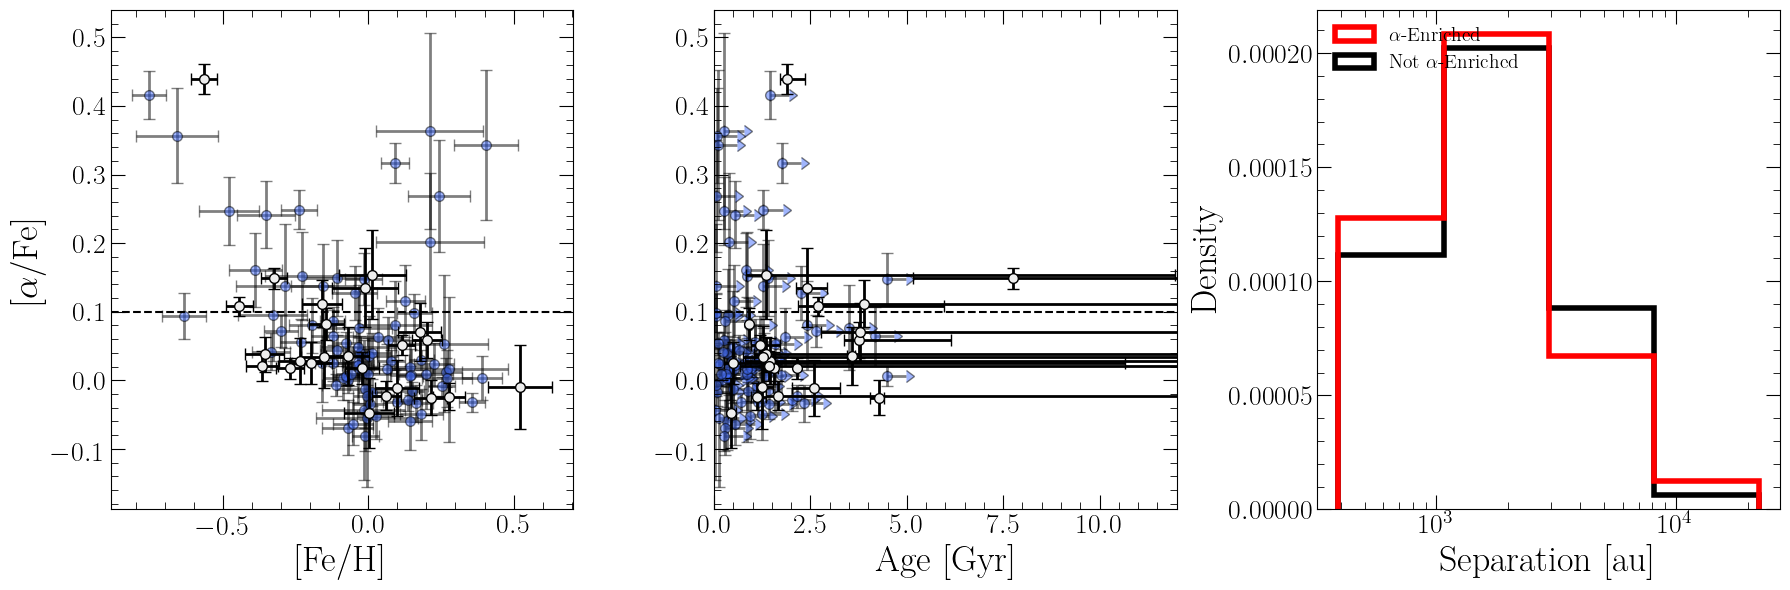

In [19]:
#### alpha-enriched stars

fig, ax = plt.subplots(ncols=3, figsize=(18, 6), sharey=False)

a_ENRICHED_CUTOFF = 0.1

## alpha_fe-fe_h relation

ax[0].errorbar(
    combined.loc[totalage,"fe_h"], 
    combined.loc[totalage,"alpha_fe"], 
    xerr=combined.loc[totalage,"e_fe_h"],
    yerr=combined.loc[totalage,"e_alpha_fe"],
    fmt="o", color="#eeeeee", markeredgecolor="k", ecolor="k", lw=2, capsize=4, markersize=7
)

ax[0].errorbar(
    combined.loc[coolingage,"fe_h"], 
    combined.loc[coolingage,"alpha_fe"], 
    xerr=combined.loc[coolingage,"e_fe_h"],
    yerr=combined.loc[coolingage,"e_alpha_fe"], alpha=0.5,
    fmt="o", color="#426dfc", markeredgecolor="k", ecolor="k", lw=2, capsize=4, markersize=7, zorder=0
)
ax[0].axhline(y=a_ENRICHED_CUTOFF, c="k", ls="--")
ax[0].set_xlabel("[Fe/H]") ; ax[0].set_ylabel(r"[$\alpha$/Fe]")

## Age-alpha relation

ax[1].errorbar(
    combined.loc[totalage,"tot_age"], 
    combined.loc[totalage,"alpha_fe"], 
    xerr=combined.loc[totalage,["tot_age_error_lower", "tot_age_error_upper"]].values.T, 
    yerr=combined.loc[totalage,"e_alpha_fe"],
    fmt="o", color="#eeeeee", markeredgecolor="k", ecolor="k", lw=2, capsize=4, markersize=7
)

ax[1].errorbar(
    combined.loc[coolingage,"cool_age"], 
    combined.loc[coolingage,"alpha_fe"], 
    xerr=0.5, xlolims=True, alpha=0.5,
    yerr=combined.loc[coolingage,"e_alpha_fe"],
    fmt="o", color="#426dfc", markeredgecolor="k", ecolor="k", lw=2, capsize=4, markersize=7, zorder=0
)
ax[1].axhline(y=a_ENRICHED_CUTOFF, c="k", ls="--")
ax[1].set_xlabel("Age [Gyr]")
ax[1].set_xlim(0, 12)
ax[1].sharey(ax[0])

## Separation Histograms

a_enriched = (combined.loc[:,"alpha_fe"] > a_ENRICHED_CUTOFF)
not_a_enriched = (combined.loc[:,"alpha_fe"] <= a_ENRICHED_CUTOFF)

sep_bins = np.logspace(
    min(np.log10(np.min(combined.loc[a_enriched, "sep_AU"])), np.log10(np.min(combined.loc[not_a_enriched, "sep_AU"]))),
    max(np.log10(np.max(combined.loc[a_enriched, "sep_AU"])), np.log10(np.max(combined.loc[not_a_enriched, "sep_AU"]))), 
    5
)

ax[2].hist(combined.loc[a_enriched, "sep_AU"], bins=sep_bins, histtype="step", linewidth=4, color="red", 
           label=r"$\alpha$-Enriched", density=True)
ax[2].hist(combined.loc[not_a_enriched, "sep_AU"], bins=sep_bins, histtype="step", linewidth=4, color="k", 
           label=r"Not $\alpha$-Enriched", density=True, zorder=0)
ax[2].set_xlabel("Separation [au]") ; ax[2].set_ylabel("Density") ; ax[2].legend(framealpha=0, loc="upper left", fontsize=14)
ax[2].set_xscale("log")

fig.tight_layout()

idx = np.argmax(combined.loc[totalage, "alpha_fe"])
print(combined.loc[totalage].query("alpha_fe > 0.40")[["ms_source_id", "alpha_fe", "e_alpha_fe", "tot_age","tot_age_error_lower", "tot_age_error_upper"]])

plt.savefig("figures_original/age_alpha.pdf")

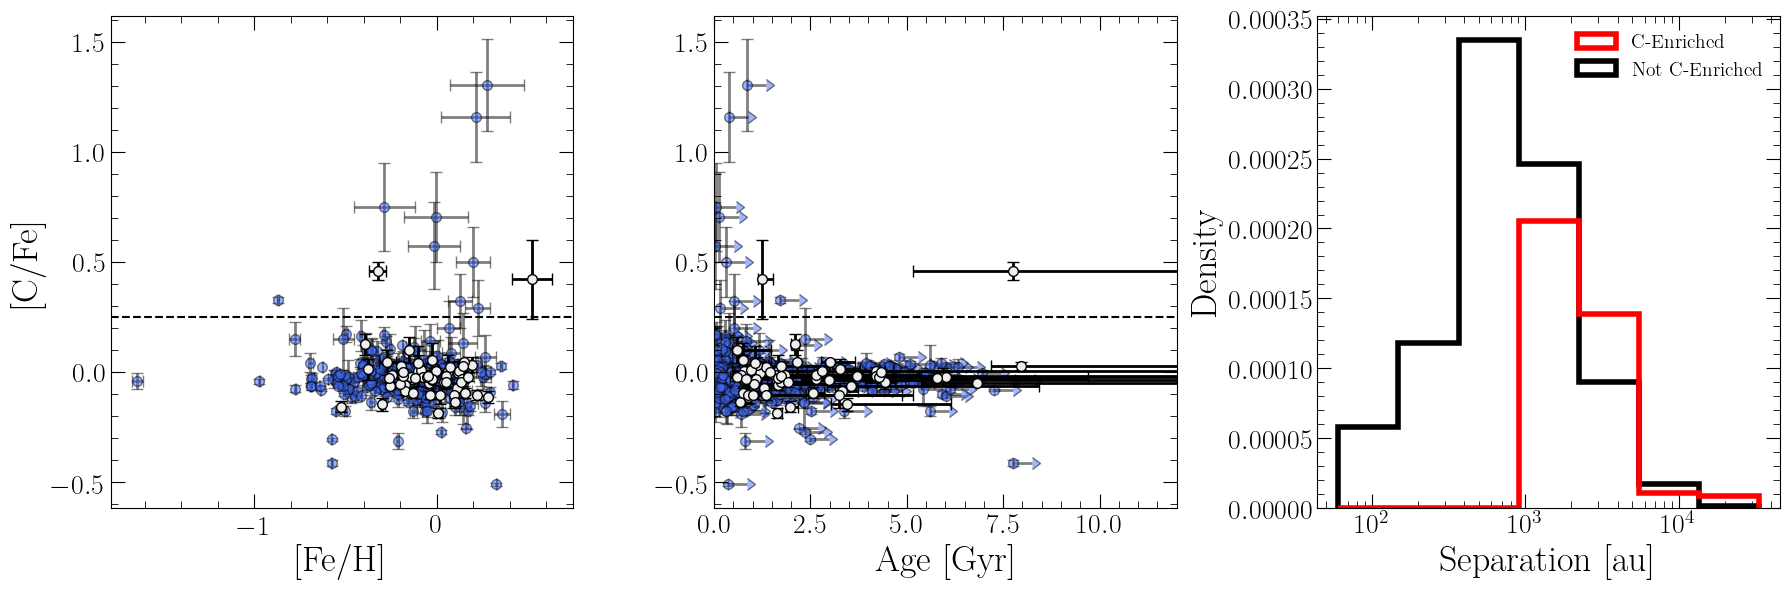

In [20]:
#### alpha-enriched stars

fig, ax = plt.subplots(ncols=3, figsize=(18, 6), sharey=False)

C_ENRICHED_CUTOFF = 0.25

## alpha_fe-fe_h relation

ax[0].errorbar(
    combined.loc[totalage,"fe_h"], 
    combined.loc[totalage,"c_fe"], 
    xerr=combined.loc[totalage,"e_fe_h"],
    yerr=combined.loc[totalage,"e_c_fe"],
    fmt="o", color="#eeeeee", markeredgecolor="k", ecolor="k", lw=2, capsize=4, markersize=7
)

ax[0].errorbar(
    combined.loc[coolingage,"fe_h"], 
    combined.loc[coolingage,"c_fe"], 
    xerr=combined.loc[coolingage,"e_fe_h"],
    yerr=combined.loc[coolingage,"e_c_fe"], alpha=0.5,
    fmt="o", color="#426dfc", markeredgecolor="k", ecolor="k", lw=2, capsize=4, markersize=7, zorder=0
)
ax[0].axhline(y=C_ENRICHED_CUTOFF, c="k", ls="--")
ax[0].set_xlabel("[Fe/H]") ; ax[0].set_ylabel(r"[C/Fe]")

## Age-alpha relation

ax[1].errorbar(
    combined.loc[totalage,"tot_age"], 
    combined.loc[totalage,"c_fe"], 
    xerr=combined.loc[totalage,["tot_age_error_lower", "tot_age_error_upper"]].values.T, 
    yerr=combined.loc[totalage,"e_c_fe"],
    fmt="o", color="#eeeeee", markeredgecolor="k", ecolor="k", lw=2, capsize=4, markersize=7
)

ax[1].errorbar(
    combined.loc[coolingage,"cool_age"], 
    combined.loc[coolingage,"c_fe"], 
    xerr=0.5, xlolims=True, alpha=0.5,
    yerr=combined.loc[coolingage,"e_c_fe"],
    fmt="o", color="#426dfc", markeredgecolor="k", ecolor="k", lw=2, capsize=4, markersize=7, zorder=0
)
ax[1].axhline(y=C_ENRICHED_CUTOFF, c="k", ls="--")
ax[1].set_xlabel("Age [Gyr]")
ax[1].set_xlim(0, 12)
ax[1].sharey(ax[0])

## Separation Histograms

a_enriched = (combined.loc[:,"c_fe"] > C_ENRICHED_CUTOFF)
not_a_enriched = (combined.loc[:,"c_fe"] <= C_ENRICHED_CUTOFF)

sep_bins = np.logspace(
    min(np.log10(np.min(combined.loc[a_enriched, "sep_AU"])), np.log10(np.min(combined.loc[not_a_enriched, "sep_AU"]))),
    max(np.log10(np.max(combined.loc[a_enriched, "sep_AU"])), np.log10(np.max(combined.loc[not_a_enriched, "sep_AU"]))), 
    8
)

ax[2].hist(combined.loc[a_enriched, "sep_AU"], bins=sep_bins, histtype="step", density=True,
           linewidth=4, color="red", label=r"C-Enriched")
ax[2].hist(combined.loc[not_a_enriched, "sep_AU"], bins=sep_bins, histtype="step",  density=True,
           linewidth=4, color="k", label=r"Not C-Enriched", zorder=0)
ax[2].set_xlabel("Separation [au]") ; ax[2].set_ylabel("Density") ; ax[2].legend(framealpha=0, fontsize=14)
ax[2].set_xscale("log")

fig.tight_layout()
plt.savefig("figures_original/age_carbon.pdf")

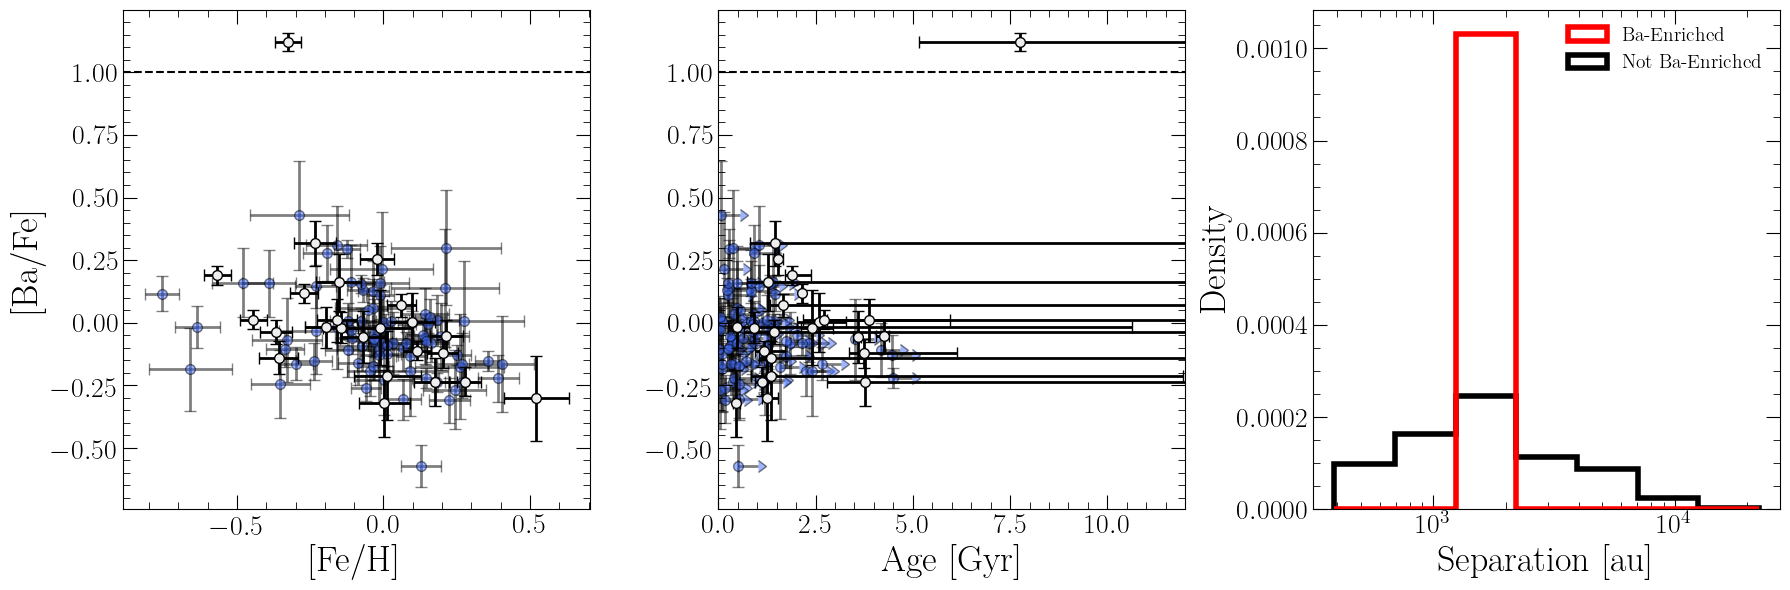

In [21]:
#### alpha-enriched stars

fig, ax = plt.subplots(ncols=3, figsize=(18, 6), sharey=False)

Ba_ENRICHED_CUTOFF = 1.0

## alpha_fe-fe_h relation

ax[0].errorbar(
    combined.loc[totalage,"fe_h"], 
    combined.loc[totalage,"ba_fe"], 
    xerr=combined.loc[totalage,"e_fe_h"],
    yerr=combined.loc[totalage,"e_ba_fe"],
    fmt="o", color="#eeeeee", markeredgecolor="k", ecolor="k", lw=2, capsize=4, markersize=7
)

ax[0].errorbar(
    combined.loc[coolingage,"fe_h"], 
    combined.loc[coolingage,"ba_fe"], 
    xerr=combined.loc[coolingage,"e_fe_h"],
    yerr=combined.loc[coolingage,"e_ba_fe"], alpha=0.5,
    fmt="o", color="#426dfc", markeredgecolor="k", ecolor="k", lw=2, capsize=4, markersize=7, zorder=0
)
ax[0].axhline(y=Ba_ENRICHED_CUTOFF, c="k", ls="--")
ax[0].set_xlabel("[Fe/H]") ; ax[0].set_ylabel(r"[Ba/Fe]")

## Age-alpha relation

ax[1].errorbar(
    combined.loc[totalage,"tot_age"], 
    combined.loc[totalage,"ba_fe"], 
    xerr=combined.loc[totalage,["tot_age_error_lower", "tot_age_error_upper"]].values.T, 
    yerr=combined.loc[totalage,"e_ba_fe"],
    fmt="o", color="#eeeeee", markeredgecolor="k", ecolor="k", lw=2, capsize=4, markersize=7
)

ax[1].errorbar(
    combined.loc[coolingage,"cool_age"], 
    combined.loc[coolingage,"ba_fe"], 
    xerr=0.5, xlolims=True, alpha=0.5,
    yerr=combined.loc[coolingage,"e_ba_fe"],
    fmt="o", color="#426dfc", markeredgecolor="k", ecolor="k", lw=2, capsize=4, markersize=7, zorder=0
)
ax[1].axhline(y=Ba_ENRICHED_CUTOFF, c="k", ls="--")
ax[1].set_xlabel("Age [Gyr]")
ax[1].set_xlim(0, 12)
ax[1].sharey(ax[0])

## Separation Histograms

a_enriched = (combined.loc[:,"ba_fe"] > Ba_ENRICHED_CUTOFF)
not_a_enriched = (combined.loc[:,"ba_fe"] <= Ba_ENRICHED_CUTOFF)

sep_bins = np.logspace(
    min(np.log10(np.min(combined.loc[a_enriched, "sep_AU"])), np.log10(np.min(combined.loc[not_a_enriched, "sep_AU"]))),
    max(np.log10(np.max(combined.loc[a_enriched, "sep_AU"])), np.log10(np.max(combined.loc[not_a_enriched, "sep_AU"]))), 
    8
)

ax[2].hist(combined.loc[a_enriched, "sep_AU"], bins=sep_bins, histtype="step", density=True,
           linewidth=4, color="red", label=r"Ba-Enriched")
ax[2].hist(combined.loc[not_a_enriched, "sep_AU"], bins=sep_bins, histtype="step",  density=True,
           linewidth=4, color="k", label=r"Not Ba-Enriched", zorder=0)
ax[2].set_xlabel("Separation [au]") ; ax[2].set_ylabel("Density") ; ax[2].legend(framealpha=0, fontsize=14)
ax[2].set_xscale("log")

fig.tight_layout()
plt.savefig("figures_original/age_barium.pdf")

In [22]:
combined.loc[a_enriched, ["tot_age_error_lower", "tot_age_error_upper"]]

,tot_age_error_lower,tot_age_error_upper
91,2.616106,999.0


In [23]:
import os, re

coolingdir = os.environ['COOLING_PATH']
paths = glob.glob(
    os.path.join(coolingdir, "feh_p000_afe_p0_wds_vvcrit0.4", "Tracks", "*"),
)
wd_masses = [
    float(re.search(r'(\d+\.\d+)(?=\.data$)', p).group(1))
    for p in paths
]

pattern = re.compile(r'#\s*M_in\s*=\s*([\d.]+)')
m_in_values = []
for path in paths:
    with open(path) as f:
        for line in f:
            match = pattern.search(line)
            if match:
                m_in_values.append(float(match.group(1)))
                break  # stop after finding it

ifmr = pd.read_csv("../data/MESA_IFMR/ifmr_data.csv")

wd_masses = np.array(wd_masses)
m_in_values = np.array(m_in_values)

idx = np.argsort(wd_masses)
wd_masses = wd_masses[idx]
m_in_values = m_in_values[idx]

0.014791400000000001


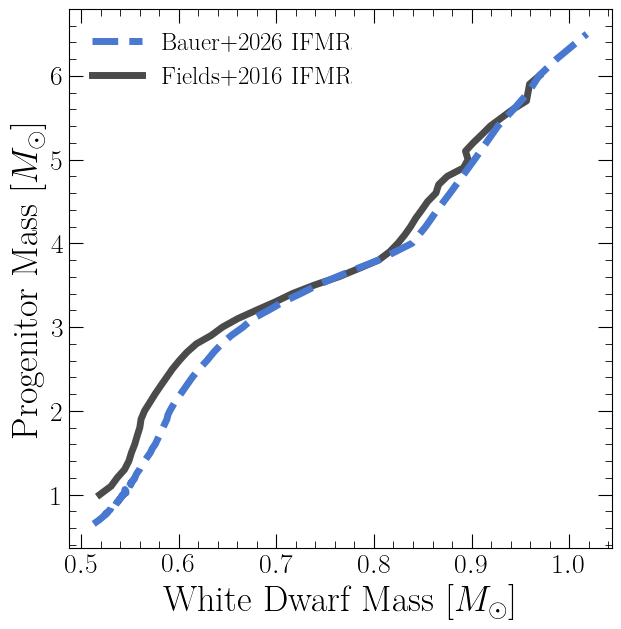

In [24]:
plt.plot(wd_masses, m_in_values, c="#4978d1", lw=5, ls="--", label="Bauer+2026 IFMR")
plt.plot(ifmr.M_final, ifmr.M_initial, c="#4b4b4b", lw=5, label="Fields+2016 IFMR", zorder=0)

plt.xlabel(r"White Dwarf Mass [$M_\odot$]")
plt.ylabel(r"Progenitor Mass [$M_\odot$]")
plt.legend(framealpha=0)

print(np.mean(np.interp(ifmr.M_initial, m_in_values, wd_masses) - ifmr.M_final))

plt.savefig("figures/ifmr_comparison.pdf")

In [27]:
data_exo = pd.read_csv("../data/tyler/WDMS_total_ages_correct_models_cut_down.csv")
data_exo['tot_age_error_upper'] = data_exo['tot_age_error_upper'].fillna(999)
data_exo = data_exo.query("Teff > 0")

# ── NEA stellar hosts ─────────────────────────────────────────────────────
stellarhosts_raw = pd.read_csv("../data/merge_data/stellarhosts.csv", comment="#")
stellarhosts_raw['gaia_dr3_id'] = stellarhosts_raw['gaia_dr3_id'].str.extract(r'(\d+)$').astype('Int64')
sh_by_gaia = stellarhosts_raw.drop_duplicates(subset=['gaia_dr3_id'])
sh_by_host = (stellarhosts_raw.drop_duplicates(subset=['hostname'])
              [['hostname', 'sy_pnum', 'gaia_dr3_id']].copy())

# ── Path 1: auto-match Tyler ms_source_id ↔ NEA gaia_dr3_id ──────────────
stellarhosts = pd.merge(
    data_exo, sh_by_gaia[['gaia_dr3_id', 'sy_pnum', 'hostname']],
    left_on='ms_source_id', right_on='gaia_dr3_id'
)
print(len(stellarhosts))

# ── Path 2: HD 118904 — in Tyler's CSV but absent from NEA ────────────────
#hd = data[data['source_id'] == 1687031031808427392].copy()
#if len(hd):
#    hd['gaia_dr3_id'] = pd.array([1687031134888475008], dtype='Int64')
#    hd['hostname'] = 'HD 118904'
#    hd['sy_pnum'] = 1
#    stellarhosts = pd.concat([stellarhosts, hd], ignore_index=True)

# ── Path 3: systems in Heintz (2025) Table 5.1 not in Tyler's CSV ─────────
# WD source_ids inferred as the dissertation ID not matching the NEA gaia_dr3_id.
# Ages hardcoded from the dissertation; tot_age=NaN where dissertation shows "–".
#dissertation_extra = [
#    (4001613814138156416, 'WASP-56 B',   0.20,  0.06, 2.70),
#    (1291955574574621056, 'TOI-3984 A',  2.60,  0.10, 0.10),
#    (pd.NA,              'TOI-3714',    8.70,  0.30, 2.10),
#    (1334573817793501696, 'HAT-P-18',   0.80,  0.10, 0.30),
#    (4984244267802428032, 'HD 8535',    np.nan, np.nan, np.nan),
#    (5380888883023786880, 'WASP-129',   np.nan, np.nan, np.nan),
#    (3578137911427752704, 'HD 109271',  np.nan, np.nan, np.nan),
#]
#extra_rows = []
#for wd_id, host, ta, te_lo, te_hi in dissertation_extra:
#    sh_row = sh_by_host[sh_by_host['hostname'] == host]
#    sy_pnum = int(sh_row['sy_pnum'].iloc[0]) if len(sh_row) else 1
#    gaia_id = int(sh_row['gaia_dr3_id'].iloc[0]) if len(sh_row) else pd.NA
#    extra_rows.append({'source_id': wd_id, 'gaia_dr3_id': gaia_id,
#                       'hostname': host, 'sy_pnum': sy_pnum,
#                       'cool_age': np.nan, 'e_cool_age_lower': np.nan, 'e_cool_age_upper': np.nan,
#                       'tot_age': ta, 'tot_age_error_lower': te_lo, 'tot_age_error_upper': te_hi,
#                       'Mass': np.nan})
#stellarhosts = pd.concat([stellarhosts, pd.DataFrame(extra_rows)], ignore_index=True)

# ── Suppress ages with unbounded IFMR error (tot_age_error_upper ≥ 900) ───
#bad = stellarhosts['tot_age_error_upper'] >= 900
#stellarhosts.loc[bad, ['tot_age', 'tot_age_error_upper', 'tot_age_error_lower']] = np.nan

# Keep reliable_age as informational metadata (not used to suppress ages here)
stellarhosts['reliable_age'] = stellarhosts['Mass'] > 0.63
len(stellarhosts)


9


9

In [71]:
stellarhosts[["source_id", "Mass", "tot_age"]]

,source_id,Mass,tot_age
0,2105915343899024512,0.688436,1.956532
1,2294170834291960832,0.587073,12.033320
2,2645940445519931520,0.328931,NaN
3,3693358792919145600,0.668289,3.128101
4,4859136199796614784,0.509167,17.223502
5,5602379190880667904,0.494133,914.666361
6,6009537829925128064,0.607049,5.410848
7,6018034958869558912,0.641780,1.084002
8,6160221736672454400,0.621060,3.801248


In [56]:
elbadry = pd.read_parquet("~/observational/catalogs/elbadry_widebinary.pqt")
elbadry = elbadry[elbadry["binary_type"] == b"WDMS"]

In [68]:
elbadry[elbadry["source_id2"] == 6160221736672454400][["source_id1", "ruwe2", "phot_bp_rp_excess_factor2", "R_chance_align"]]

,source_id1,ruwe2,phot_bp_rp_excess_factor2,R_chance_align
59640,6160221740968692992,1.027184,1.151352,0.000018


In [ ]:
stellarhosts = pd.read_csv("../data/merge_data/stellarhosts.csv", comment="#").drop_duplicates(subset=["gaia_dr3_id"])
stellarhosts['gaia_dr3_id'] = stellarhosts['gaia_dr3_id'].str.extract(r'(\d+)$').astype('Int64')
stellarhosts = pd.merge(data, stellarhosts, left_on="ms_source_id", right_on="gaia_dr3_id")
stellarhosts.loc[:, "reliable_age"] = stellarhosts.Mass > 0.63

mask = ~stellarhosts.reliable_age
stellarhosts.loc[mask, "tot_age"] = np.nan 
stellarhosts.loc[mask, "tot_age_error_upper"] = np.nan 
stellarhosts.loc[mask, "tot_age_error_lower"] = np.nan 

In [ ]:
def latex_ci(med, hi, lo, fmt="{:.2f}"):
    plus = hi
    minus = lo
    if np.isnan(med):
        return "-"
    else:
        return rf"${fmt.format(med)}^{{+{fmt.format(plus)}}}_{{-{fmt.format(minus)}}}$"

df = stellarhosts.copy()

df["wd_cool_age_tex"] = [
    latex_ci(m, h, l)
    for m, h, l in zip(df.cool_age, df.e_cool_age_upper, df.e_cool_age_lower)
]

df["wd_age_tex"] = [
    latex_ci(m, h, l)
    for m, h, l in zip(df.tot_age, df.tot_age_error_upper, df.tot_age_error_lower)
]

df[["source_id", "gaia_dr3_id","sy_pnum","wd_cool_age_tex", "wd_age_tex"]].to_latex(
    "exoplanets.tex",
    escape=False,   # critical so LaTeX math is not escaped
    index=False
)
print(len(df))

9


In [ ]:
interp_model = WD_models.interp_xy_z_func(x=model['mass_array'], y=10**model['logteff'], z=model['age_cool'])

def read_data(path: str):
    mass_i = np.load(os.path.join(path, "mi.npy"))
    mslife = np.load(os.path.join(path, "msl.npy"))
    
    idx = np.argsort(mass_i)
    mass_i = mass_i[idx]
    mslife = mslife[idx]

    mass_wd = np.interp(mass_i, ifmr.M_initial, ifmr.M_final)
    totalage = mslife + interp_model(mass_wd, 10000)
    return mass_i, mslife, mass_wd, totalage

ifmr_dir = os.path.join("..", "tyler_code", "init_mass_to_mslife")
massi_fehp025, mslife_fehp025, masswd_fehp025, totalage_fehp025 = read_data(os.path.join(ifmr_dir, "mist_feh_p025"))
massi_fehm025, mslife_fehm025, masswd_fehm025, totalage_fehm025 = read_data(os.path.join(ifmr_dir, "mist_feh_m025"))
massi_fehm050, mslife_fehm050, masswd_fehm050, totalage_fehm050 = read_data(os.path.join(ifmr_dir, "mist_feh_m050"))

massi_fehp000, mslife_fehp000, masswd_fehp000, totalage_fehp000 = read_data(os.path.join(ifmr_dir))

/tmp/ipykernel_189459/899779032.py:7: RuntimeWarning: divide by zero encountered in log10
  ax_ms.plot(masswd_fehp000[mask], np.log10(mslife_fehp000)[mask], c="k", lw=3)
/tmp/ipykernel_189459/899779032.py:14: RuntimeWarning: divide by zero encountered in log10
  np.log10(mslife_fehp000)[::-1],


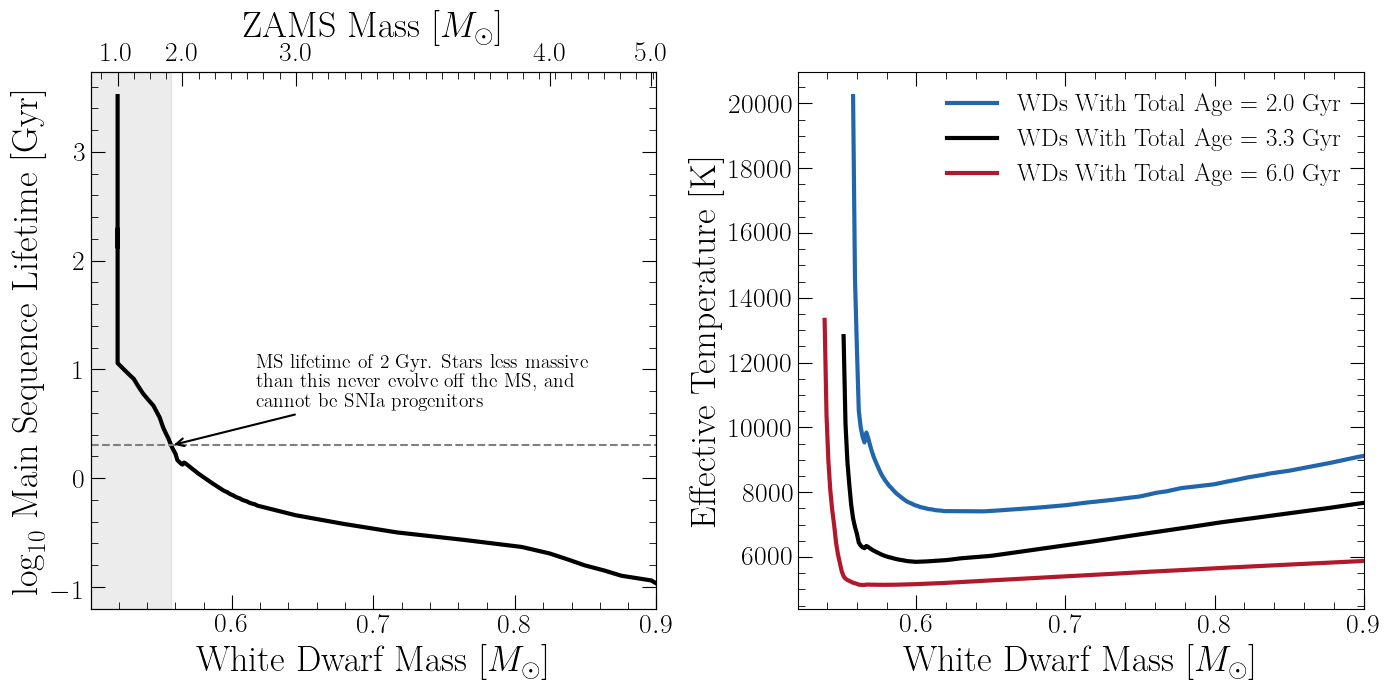

In [ ]:
from scipy.optimize import brentq

fig, (ax_ms, ax_teff) = plt.subplots(1, 2, figsize=(14, 7))

# ── Left panel: WD mass vs log MS lifetime ──────────────────────────────
mask = masswd_fehp000 < 0.91
ax_ms.plot(masswd_fehp000[mask], np.log10(mslife_fehp000)[mask], c="k", lw=3)
ax_ms.axhline(np.log10(2.0), linestyle='--', color='gray', label='3 Gyr')
xmin, _ = ax_ms.get_xlim()
ax_ms.set_xlim(xmin, 0.90)

intersection_wd = np.interp(
    np.log10(2.0),
    np.log10(mslife_fehp000)[::-1],
    masswd_fehp000[::-1],
)
ax_ms.axvspan(ax_ms.get_xlim()[0], intersection_wd, alpha=0.15, color='gray', zorder=0)

# ── Annotated arrow at intersection point ──────────────────────────────
intersection_y = np.log10(2.0)
ax_ms.annotate(
    f"MS lifetime of 2 Gyr. Stars less massive\n" 
    +"than this never evolve off the MS, and\n"
    + "cannot be SNIa progenitors",
    xy=(intersection_wd, intersection_y),
    xytext=(intersection_wd + 0.06, intersection_y + 0.35),
    fontsize=14,
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
    ha='left',
)

ax_ms.set_xlabel(r"White Dwarf Mass [$M_\odot$]")
ax_ms.set_ylabel(r"$\log_{10}$ Main Sequence Lifetime [Gyr]")

ifmr_sorted = ifmr.sort_values("M_initial")
ax_ms_top = ax_ms.twiny()
ax_ms_top.set_xlim(ax_ms.get_xlim())

zams_ticks = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
valid = (zams_ticks >= ifmr_sorted.M_initial.min()) & (zams_ticks <= ifmr_sorted.M_initial.max())
zams_ticks = zams_ticks[valid]
wd_tick_positions = np.interp(zams_ticks, ifmr_sorted.M_initial, ifmr_sorted.M_final)
ax_ms_top.set_xticks(wd_tick_positions)
ax_ms_top.set_xticklabels([f"{m:.1f}" for m in zams_ticks])
ax_ms_top.set_xlabel(r"ZAMS Mass [$M_\odot$]")

# ── Right panel: isochrones in WD mass vs Teff ─────────────────────────
# For a given total age: cooling_age = total_age - ms_lifetime(M_WD)
# Invert interp_model(mass, teff) → cooling age to find teff at each mass.
def teff_isochrone(total_age):
    masses, teffs = [], []
    for M in np.linspace(masswd_fehp000.min(), 0.90, 300):
        ms_life = np.interp(M, masswd_fehp000, mslife_fehp000)
        cool_age = total_age - ms_life
        if cool_age <= 0:
            continue
        try:
            T = brentq(lambda T: interp_model(M, T) - cool_age, 2000, 80000)
            masses.append(M)
            teffs.append(T)
        except Exception as e:
            print(e)
    return masses, teffs

isochrones = [
    (2.0, "#2166ac"),
    (3.3, "k"),
    (6.0, "#b2182b"),
]
for total_age, color in isochrones:
    masses, teffs = teff_isochrone(total_age)
    ax_teff.plot(masses, teffs, lw=3, color=color, label=f"WDs With Total Age = {total_age} Gyr")

ax_teff.set_xlabel(r"White Dwarf Mass [$M_\odot$]")
ax_teff.set_ylabel(r"Effective Temperature [K]")
ax_teff.legend(framealpha=0)
xmin, _ = ax_teff.get_xlim()
ax_teff.set_xlim(xmin, 0.90)

fig.tight_layout()
plt.show()

In [ ]:
mass_curve

array([0.54940635, 0.55091167, 0.55241699, 0.55392231, 0.55542763,
       0.55693294, 0.55843826, 0.55994358, 0.5614489 , 0.56295421,
       0.56445953, 0.56596485, 0.56747017, 0.56897548, 0.5704808 ,
       0.57198612, 0.57349144, 0.57499676, 0.57650207, 0.57800739,
       0.57951271, 0.58101803, 0.58252334, 0.58402866, 0.58553398,
       0.5870393 , 0.58854462, 0.59004993, 0.59155525, 0.59306057,
       0.59456589, 0.5960712 , 0.59757652, 0.59908184, 0.60058716,
       0.60209247, 0.60359779, 0.60510311, 0.60660843, 0.60811375,
       0.60961906, 0.61112438, 0.6126297 , 0.61413502, 0.61564033,
       0.61714565, 0.61865097, 0.62015629, 0.62166161, 0.62316692,
       0.62467224, 0.62617756, 0.62768288, 0.62918819, 0.63069351,
       0.63219883, 0.63370415, 0.63520946, 0.63671478, 0.6382201 ,
       0.63972542, 0.64123074, 0.64273605, 0.64424137, 0.64574669,
       0.64725201, 0.64875732, 0.65026264, 0.65176796, 0.65327328,
       0.6547786 , 0.65628391, 0.65778923, 0.65929455, 0.66079

/tmp/ipykernel_189459/1383913578.py:7: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(masswd_fehp025, (mslife_fehp025 - mslife_fehp000) / mslife_fehp000, lw=3, c=fehp025_color)
/tmp/ipykernel_189459/1383913578.py:8: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(masswd_fehm025, (mslife_fehm025 - mslife_fehp000) / mslife_fehp000, lw=3, c=fehm025_color)
/tmp/ipykernel_189459/1383913578.py:9: RuntimeWarning: divide by zero encountered in divide
  ax[0].plot(masswd_fehp025, (mslife_fehm050 - mslife_fehp000) / mslife_fehp000, lw=3, c=fehm050_color)


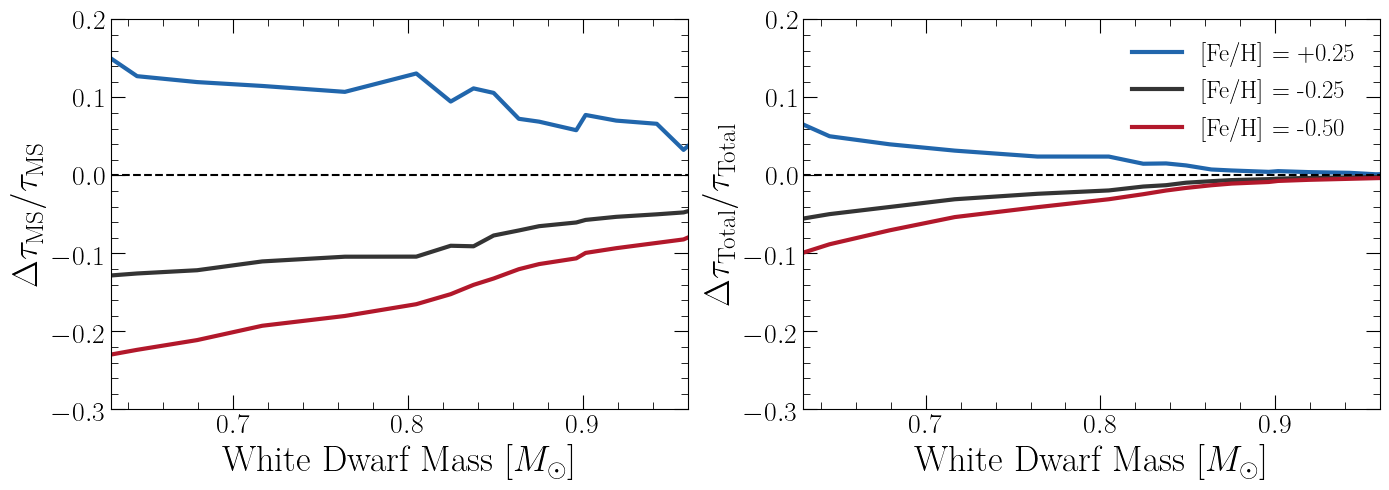

In [ ]:
fig, ax = plt.subplots(ncols=2, figsize=(14, 5))

fehp025_color = "#2166ac"
fehm025_color = "#343434"
fehm050_color = "#b2182b"

ax[0].plot(masswd_fehp025, (mslife_fehp025 - mslife_fehp000) / mslife_fehp000, lw=3, c=fehp025_color)
ax[0].plot(masswd_fehm025, (mslife_fehm025 - mslife_fehp000) / mslife_fehp000, lw=3, c=fehm025_color)
ax[0].plot(masswd_fehp025, (mslife_fehm050 - mslife_fehp000) / mslife_fehp000, lw=3, c=fehm050_color)
ax[0].axhline(0, c="k", ls="--")
ax[0].set_xlim(0.63, 0.96) ; ax[0].set_ylim(-0.3, 0.2)
ax[0].set_xlabel(r"White Dwarf Mass [$M_\odot$]")
ax[0].set_ylabel(r"$\Delta \tau_\text{MS} / \tau_\text{MS}$")

ax[1].plot(masswd_fehp025, (totalage_fehp025 - totalage_fehp000) / totalage_fehp000, lw=3, label=r"[Fe/H] = +0.25", c=fehp025_color)
ax[1].plot(masswd_fehm025, (totalage_fehm025 - totalage_fehp000) / totalage_fehp000, lw=3, label=r"[Fe/H] = -0.25", c=fehm025_color)
ax[1].plot(masswd_fehp025, (totalage_fehm050 - totalage_fehp000) / totalage_fehp000, lw=3, label=r"[Fe/H] = -0.50", c=fehm050_color)
ax[1].axhline(0, c="k", ls="--")
ax[1].set_xlim(0.63, 0.96) ; ax[1].set_ylim(-0.3, 0.2)
ax[1].set_xlabel(r"White Dwarf Mass [$M_\odot$]")
ax[1].set_ylabel(r"$\Delta \tau_\text{Total} / \tau_\text{Total}$")
ax[1].legend(framealpha=0)

fig.tight_layout()
fig.savefig("figures_original/metallicity_model.pdf")

In [ ]:
from astropy.coordinates import SkyCoord
import astropy.units as u

coolwd = data.query("Teff < 6000").copy()
print(f"no. cool wds in the sample: {len(coolwd)}")

# Rotate ICRS proper motions to Galactic frame
coords = SkyCoord(
    ra=coolwd['ra'].values * u.deg,
    dec=coolwd['dec'].values * u.deg,
    pm_ra_cosdec=coolwd['pmra'].values * u.mas / u.yr,
    pm_dec=coolwd['pmdec'].values * u.mas / u.yr,
    frame='icrs'
)
gal = coords.galactic
pm_l_cosb = gal.pm_l_cosb.to(u.mas / u.yr).value
pm_b      = gal.pm_b.to(u.mas / u.yr).value

# km/s: v = 4.74047 * mu[mas/yr] * d[kpc]
d_kpc = 1.0 / coolwd['wtd_par'].values  # wtd_par in mas
v_l_helio = 4.74047 * pm_l_cosb * d_kpc
v_b_helio = 4.74047 * pm_b      * d_kpc

# Solar motion correction (Schönrich et al. 2010 via Cheng 2019)
U_sun, V_sun, W_sun = 11.0, 12.0, 7.0  # km/s
l_rad = np.radians(coolwd['l'].values)
b_rad = np.radians(coolwd['b'].values)

v_l_sun = -U_sun * np.sin(l_rad) + V_sun * np.cos(l_rad)
v_b_sun = (-U_sun * np.cos(l_rad) * np.sin(b_rad)
           -V_sun * np.sin(l_rad) * np.sin(b_rad)
           +W_sun * np.cos(b_rad))

coolwd['v_l'] = v_l_helio - v_l_sun
coolwd['v_b'] = v_b_helio - v_b_sun

# Absolute values for the histograms
coolwd['abs_v_l'] = np.abs(coolwd['v_l'])
coolwd['abs_v_b'] = np.abs(coolwd['v_b'])

print(f'sigma_l = {coolwd["v_l"].std():.1f} km/s')
print(f'sigma_b = {coolwd["v_b"].std():.1f} km/s')

no. cool wds in the sample: 1862
sigma_l = 54.7 km/s
sigma_b = 38.8 km/s


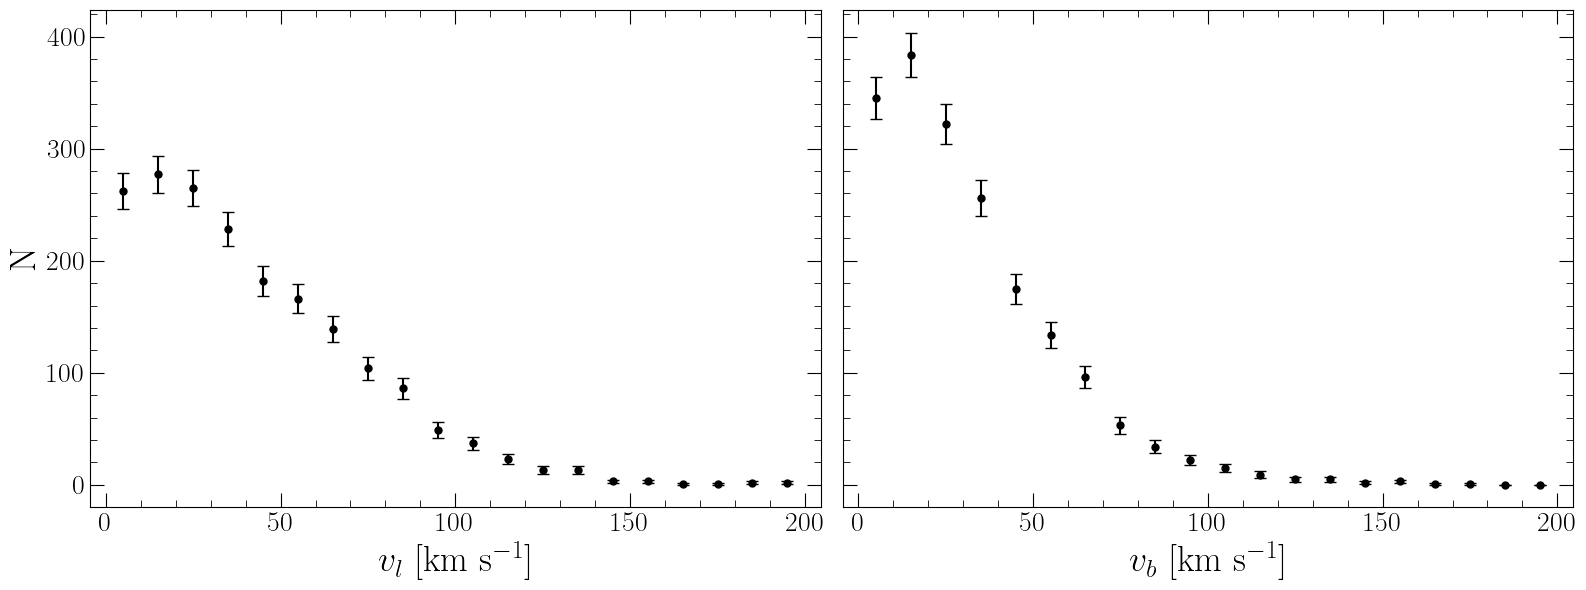

In [ ]:
# Histogram bins: 0-100 km/s, 10 bins of 10 km/s
bins = np.arange(0, 201, 10)
bw   = 10.0
bc   = 0.5 * (bins[:-1] + bins[1:])  # centers: 5, 15, ..., 95

counts_l, _ = np.histogram(np.abs(coolwd['v_l']), bins=bins)
counts_b, _ = np.histogram(np.abs(coolwd['v_b']), bins=bins)

fig, ax = plt.subplots(ncols=2, figsize=(16, 6), sharey=True)

ax[0].errorbar(bc, counts_l, yerr=np.sqrt(counts_l), fmt='o', c='k', capsize=4);
ax[0].set_xlabel(r"$v_l$ [km s$^{-1}$]") ; ax[0].set_ylabel("N")

ax[1].errorbar(bc, counts_b, yerr=np.sqrt(counts_b), fmt='o', c='k', capsize=4);
ax[1].set_xlabel(r"$v_b$ [km s$^{-1}$]")

fig.tight_layout()
fig.savefig("figures_original/coolwd_avr.pdf")